# STIC-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the STIC-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the STIC-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the PT-JPL-SM model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [2]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from BESS_JPL import process_BESS_table
from STIC_JPL import process_STIC_table, load_ECOv002_calval_STIC_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [3]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out rows where `fAPARmax` is zero. The resulting DataFrame is displayed for inspection.

In [4]:
input_df = load_ECOv002_calval_STIC_inputs()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,KG_climate,CI,canopy_height_meters,COT,AOT,Ca,wind_speed_mps,vapor_gccm,ozone_cm,Rn_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,3,0.282353,20.642902,0,0,400,0,0,0.3,393.85710
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,4,0.286275,0.000000,0,0,400,0,0,0.3,643.47500
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,4,0.286275,0.000000,0,0,400,0,0,0.3,628.76870
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,4,0.286275,0.000000,0,0,400,0,0,0.3,626.95960
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,4,0.286275,0.000000,0,0,400,0,0,0.3,513.13380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,3,0.301961,0.000000,0,0,400,0,0,0.3,163.24739
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,3,0.301961,0.000000,0,0,400,0,0,0.3,166.19196
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,3,0.301961,0.000000,0,0,400,0,0,0.3,235.88159
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,3,0.301961,0.000000,0,0,400,0,0,0.3,247.87890


In [25]:
input_df = input_df[input_df.ST_C <= 50]

## Define Processing Function for Model Table

This cell defines a helper function that processes the input DataFrame through the Verma net radiation calculation and then the PT-JPL-SM model. This function is used in later analysis steps.

In [26]:
def forward_process(input_df: pd.DataFrame) -> pd.DataFrame:
    return process_STIC_table(
        # input_df=verma_net_radiation_table(input_df), 
        input_df=process_BESS_table(input_df),
        constrain_negative_LE=False,
        supply_SWin=False,
        upscale_to_daylight=True
    )

## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [27]:
processed = forward_process(input_df)
processed

[2025-12-11 09:41:48 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:41:48 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:41:48 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:41:48 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:41:48 INFO] variable elevation_m min: 1.000 mean: 980.511 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable Ta_C min: -14.605 mean: 21.858 max: 39.319 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable RH min: 0.273 mean: 0.430 max: 0.984 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable NDVI_minimum min: -0.033 mean: 0.176 max: 0.591 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable NDVI_maximum min: 0.314 mean: 0.636 max: 0.918 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable C4_fraction min: 0.000 mean: 0.284 max: 0.939 nan: 0.00% (nan)
[2025-12-11 09:41:48 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 ma

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_canopy_Wm2,G_Wm2,LE_max_change,iteration,LE_change,PT,PET_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,305.913115,70.388796,1.88147,25,0.000000,780.080320,903.223581,324.983069,324.983069,5.580687
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,307.581556,94.207955,1.88147,25,0.000224,681.705122,719.102200,386.699066,204.052841,4.511142
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,386.269419,102.383500,1.88147,25,0.002299,663.283310,706.163925,411.414467,289.724685,6.399749
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,310.398862,76.011494,1.88147,25,0.000229,613.688670,652.117099,397.397729,217.795473,4.804323
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,248.071960,68.180147,1.88147,25,0.000169,510.002412,540.700637,352.017129,188.009002,4.144802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,68.011811,5.915104,1.88147,25,0.078808,246.372719,314.434613,179.535304,98.924149,1.405046
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,151.396221,24.734355,1.88147,25,0.293414,352.514664,396.944787,284.897925,241.446194,4.308168
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,6.443778,53.271559,1.88147,25,0.000000,2557.752185,2557.752185,415.735084,7.602144,0.143013
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,67.932170,25.234056,1.88147,25,0.000001,248.806850,287.536882,271.164947,81.926659,1.549778


In [28]:
processed = processed.dropna(subset=['LEcorr50', 'ET_daylight_kg', 'ST_C'])
processed

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_canopy_Wm2,G_Wm2,LE_max_change,iteration,LE_change,PT,PET_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,305.913115,70.388796,1.88147,25,0.000000,780.080320,903.223581,324.983069,324.983069,5.580687
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,307.581556,94.207955,1.88147,25,0.000224,681.705122,719.102200,386.699066,204.052841,4.511142
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,386.269419,102.383500,1.88147,25,0.002299,663.283310,706.163925,411.414467,289.724685,6.399749
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,310.398862,76.011494,1.88147,25,0.000229,613.688670,652.117099,397.397729,217.795473,4.804323
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,248.071960,68.180147,1.88147,25,0.000169,510.002412,540.700637,352.017129,188.009002,4.144802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,68.011811,5.915104,1.88147,25,0.078808,246.372719,314.434613,179.535304,98.924149,1.405046
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,151.396221,24.734355,1.88147,25,0.293414,352.514664,396.944787,284.897925,241.446194,4.308168
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,6.443778,53.271559,1.88147,25,0.000000,2557.752185,2557.752185,415.735084,7.602144,0.143013
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,67.932170,25.234056,1.88147,25,0.000001,248.806850,287.536882,271.164947,81.926659,1.549778


## Accuracy Comparison of In-Situ Latent Heat Flux to STIC-JPL Evapotranspiration

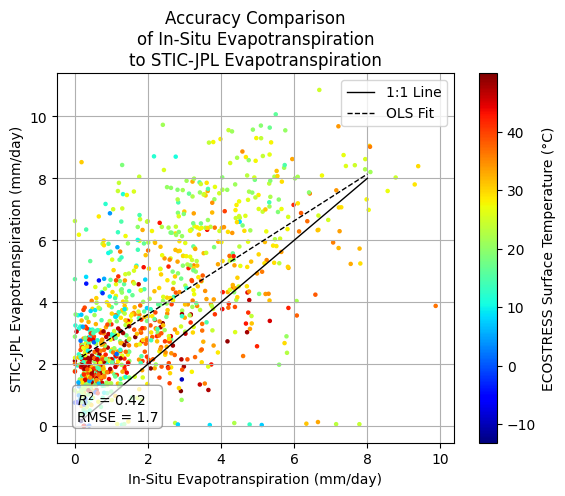

In [29]:
x_variable = "insitu_ET_daylight_kg"
y_variable = "ET_daylight_kg"

sc = plt.scatter(
    x=processed[x_variable],
    y=processed[y_variable],
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Calculate 5% and 95% tails for x and y variables
x_5th, x_95th = np.percentile(processed[x_variable], [5, 95])
y_5th, y_95th = np.percentile(processed[y_variable], [5, 95])

min_val = min(x_5th, y_5th)
max_val = max(x_95th, y_95th)

# Add 1-to-1 line
# min_val = min(processed[x_variable].min(), processed[y_variable].min())
# max_val = max(processed[x_variable].max(), processed[y_variable].max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed[x_variable], processed[y_variable], 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed[y_variable]
y_pred = coefs[0] * processed[x_variable] + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot in lower left corner
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.05), xycoords='axes fraction',
             ha='left', va='bottom',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
# xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# plt.xticks(xticks)
# plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Evapotranspiration (mm/day)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Accuracy Comparison\nof In-Situ Evapotranspiration\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend(loc='upper right')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Evapotranspiration

This cell creates a scatter plot comparing ECOSTRESS surface temperature to STIC-JPL latent heat flux for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

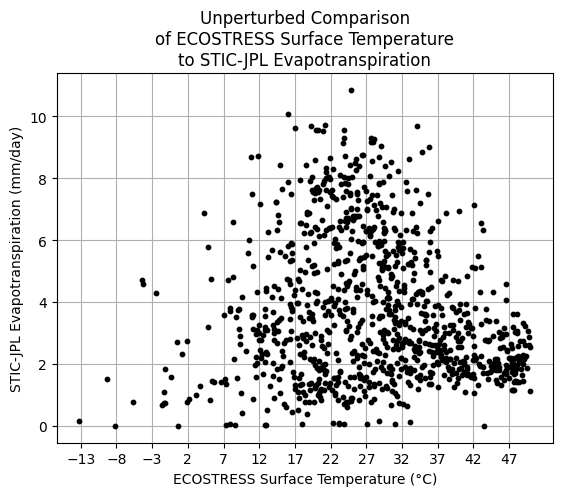

In [30]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

## Further Filter Input Data and Check Temperature Range

This cell applies additional filters to the input data, ensuring only valid `NDVI` values are included. It also checks the minimum and maximum surface temperature values in the filtered dataset.

In [31]:
# input_df = pd.read_csv(input_filename)
input_df = load_ECOv002_calval_STIC_inputs()

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

np.nanmin(input_df.ST_C), np.nanmax(input_df.ST_C)

(np.float64(-13.189999999999998), np.float64(86.11000000000001))

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [32]:
len(input_df)

1063

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the PM-JPL model. The results are displayed for further analysis.

In [33]:
input_variable = "ST_C"
output_variable = "ET_daylight_kg"

results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=forward_process,
    normalization_function=normalization_function
)

results

[2025-12-11 09:43:45 INFO] tarting Monte Carlo perturbed run
[2025-12-11 09:43:45 INFO] calculating standard deviation of input variable: ST_C
[2025-12-11 09:43:45 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-11 09:43:45 INFO] starting forward process
[2025-12-11 09:43:45 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:43:45 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:43:45 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:43:45 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:43:45 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:43:45 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-11 09:43:45 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-12-11 09:43:45 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[202

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


[2025-12-11 09:43:46 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:43:47 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:43:47 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:43:48 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:43:50 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable C4_fraction min: 0.000 mean: 0.296 max: 0.939 nan: 0.00% (nan)
[2025-12-11 09:43:50 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 ma

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


[2025-12-11 09:44:01 INFO] completed daily ET upscaling (elapsed: 2.02 seconds)
[2025-12-11 09:44:01 INFO] completed forward process for perturbed input
[2025-12-11 09:44:01 INFO] normalizing output perturbations
[2025-12-11 09:44:01 INFO] Monte Carlo run complete


,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,ET_daylight_kg,31.95,-0.954586,0.029877,30.995414,5.580687,0.219732,0.039374,5.800419
1,ST_C,ET_daylight_kg,31.95,6.231878,0.195051,38.181878,5.580687,-2.475876,0.443651,3.104811
2,ST_C,ET_daylight_kg,31.95,-3.698237,0.115751,28.251763,5.580687,-5.521466,0.989388,0.059221
3,ST_C,ET_daylight_kg,31.95,-0.065338,0.002045,31.884662,5.580687,0.01075,0.001926,5.591437
4,ST_C,ET_daylight_kg,31.95,-1.190094,0.037249,30.759906,5.580687,0.27896,0.049987,5.859647
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,ET_daylight_kg,41.61,17.277660,0.415229,58.88766,3.158022,-2.176355,0.689151,0.981667
106296,ST_C,ET_daylight_kg,41.61,6.857225,0.164798,48.467225,3.158022,-1.169222,0.370239,1.988800
106297,ST_C,ET_daylight_kg,41.61,31.509462,0.757257,73.119462,3.158022,-2.694707,0.853289,0.463315
106298,ST_C,ET_daylight_kg,41.61,-1.693178,0.040692,39.916822,3.158022,0.374127,0.118469,3.532148


## Filter Out NaN Results

This cell removes any rows with missing values from the perturbed results to ensure only valid data points are used in subsequent analysis and plotting.

In [34]:
filtered_results = results.dropna()
filtered_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,ET_daylight_kg,31.95,-0.954586,0.029877,30.995414,5.580687,0.219732,0.039374,5.800419
1,ST_C,ET_daylight_kg,31.95,6.231878,0.195051,38.181878,5.580687,-2.475876,0.443651,3.104811
2,ST_C,ET_daylight_kg,31.95,-3.698237,0.115751,28.251763,5.580687,-5.521466,0.989388,0.059221
3,ST_C,ET_daylight_kg,31.95,-0.065338,0.002045,31.884662,5.580687,0.01075,0.001926,5.591437
4,ST_C,ET_daylight_kg,31.95,-1.190094,0.037249,30.759906,5.580687,0.27896,0.049987,5.859647
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,ET_daylight_kg,41.61,17.277660,0.415229,58.88766,3.158022,-2.176355,0.689151,0.981667
106296,ST_C,ET_daylight_kg,41.61,6.857225,0.164798,48.467225,3.158022,-1.169222,0.370239,1.988800
106297,ST_C,ET_daylight_kg,41.61,31.509462,0.757257,73.119462,3.158022,-2.694707,0.853289,0.463315
106298,ST_C,ET_daylight_kg,41.61,-1.693178,0.040692,39.916822,3.158022,0.374127,0.118469,3.532148


## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in PM-JPL latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

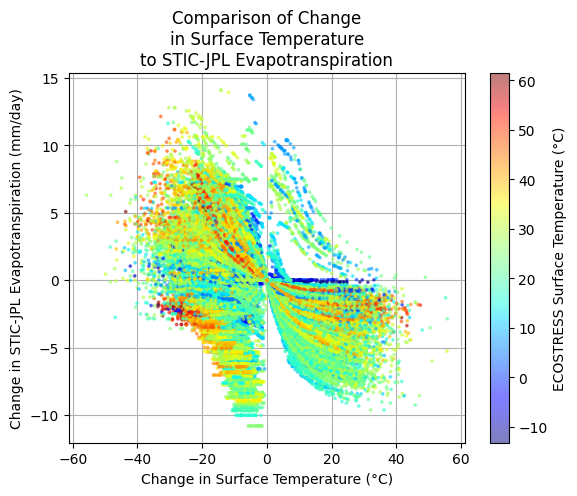

In [36]:
sc = plt.scatter(
    x=results.input_perturbation, 
    y=results.output_perturbation, 
    c=results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in STIC-JPL Evapotranspiration (mm/day)")
plt.title("Comparison of Change\nin Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [37]:
correlation = mstats.pearsonr(
    np.array(filtered_results.input_perturbation_std).astype(np.float64), 
    np.array(filtered_results.output_perturbation_std).astype(np.float64)
)[0]

correlation

np.float64(0.07684123534945113)

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [38]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["ET_daylight_kg"]

perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=forward_process,
    normalization_function=normalization_function
)

sensitivity_metrics_df

[2025-12-11 09:46:44 INFO] tarting Monte Carlo perturbed run
[2025-12-11 09:46:44 INFO] calculating standard deviation of input variable: ST_C
[2025-12-11 09:46:44 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-11 09:46:44 INFO] starting forward process
[2025-12-11 09:46:44 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:46:44 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:46:44 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:46:44 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:46:44 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:46:44 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-11 09:46:44 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-12-11 09:46:44 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[202

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


[2025-12-11 09:46:45 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:46:46 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:46:46 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:46:46 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:46:48 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable C4_fraction min: 0.000 mean: 0.296 max: 0.939 nan: 0.00% (nan)
[2025-12-11 09:46:48 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 ma

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


[2025-12-11 09:46:59 INFO] completed daily ET upscaling (elapsed: 2.01 seconds)
[2025-12-11 09:46:59 INFO] completed forward process for perturbed input
[2025-12-11 09:46:59 INFO] normalizing output perturbations
[2025-12-11 09:46:59 INFO] Monte Carlo run complete
[2025-12-11 09:47:00 INFO] tarting Monte Carlo perturbed run
[2025-12-11 09:47:00 INFO] calculating standard deviation of input variable: NDVI
[2025-12-11 09:47:00 INFO] input variable NDVI standard deviation: 0.24919504831147038
[2025-12-11 09:47:00 INFO] starting forward process
[2025-12-11 09:47:00 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:47:00 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:47:00 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:47:00 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:47:00 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-11 09:47:00 INFO

...

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/BESS_JPL/canopy_energy_balance.py:70: RuntimeWarning: divide by zero encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]
/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/BESS_JPL/canopy_energy_balance.py:76: RuntimeWarning: divide by zero encountered in divide
  rs = 1.0 / (gs1 / cf * 1e-2)  # [s m-1]
/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/BESS_JPL/canopy_energy_balance.py:70: RuntimeWarning: invalid value encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]


[2025-12-11 09:47:57 INFO] started extracting geometry from PT-JPL-SM input table
[2025-12-11 09:47:58 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-11 09:47:58 INFO] started extracting time from PT-JPL-SM input table
[2025-12-11 09:47:58 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-11 09:48:00 INFO] variable Ms min: 0.000 mean: 0.237 max: 1.000 nan: 0.00% (nan)
[2025-12-11 09:48:00 INFO] running STIC iteration 1 / 30
[2025-12-11 09:48:00 INFO] using variable Priestley-Taylor alpha with mean: 1.247
[2025-12-11 09:48:00 INFO] completed STIC iteration 1 / 30 with max LE change: 1096.908 (0.03797620898694731 seconds)
[2025-12-11 09:48:00 INFO] variable SM_1 min: 0.000 mean: 0.157 max: 1.000 nan: 0.00% (nan)
[2025-12-11 09:48:00 INFO] variable G_1 min: 0.000 mean: 58.535 max: 176.482 nan: 0.00% (nan)
[2025-12-11 09:48:00 INFO] variable LE_1 min: -155.521 mean: 247.750 max: 912.841 nan: 0.00% (nan)
[2025-12-11 09:48:00 INFO] running STIC iter

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.10/site-packages/daylight_evapotranspiration/daylight_evapotranspiration.py:126: RuntimeWarning: invalid value encountered in divide
  return rt.where((LE == 0) | ((Rn - G) == 0), 0, LE / (Rn - G))


[2025-12-11 09:48:03 INFO] completed daily ET upscaling (elapsed: 1.99 seconds)
[2025-12-11 09:48:03 INFO] completed forward process for perturbed input
[2025-12-11 09:48:03 INFO] normalizing output perturbations
[2025-12-11 09:48:03 INFO] Monte Carlo run complete


,input_variable,output_variable,metric,value
0,ST_C,ET_daylight_kg,correlation,0.050789
0,ST_C,ET_daylight_kg,r2,0.002580
0,ST_C,ET_daylight_kg,mean_normalized_change,1.920763
0,NDVI,ET_daylight_kg,correlation,0.534741
0,NDVI,ET_daylight_kg,r2,0.285948
0,NDVI,ET_daylight_kg,mean_normalized_change,0.147993
0,albedo,ET_daylight_kg,correlation,0.502673
0,albedo,ET_daylight_kg,r2,0.252680
0,albedo,ET_daylight_kg,mean_normalized_change,0.058889
0,Ta_C,ET_daylight_kg,correlation,-0.004213


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the PT-JPL-SM label.

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_59550/1799347127.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


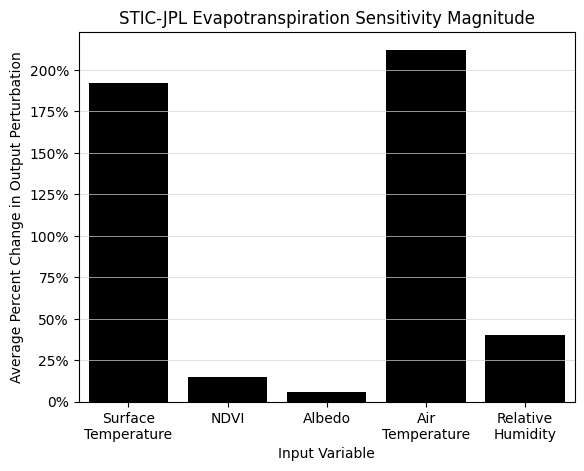

In [40]:
df = sensitivity_metrics_df
df = df[(df.output_variable == "ET_daylight_kg") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("STIC-JPL Evapotranspiration Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("STIC-JPL Evapotranspiration Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("STIC-JPL Evapotranspiration Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')
plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the PT-JPL-SM model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.